# IMPORTANT NOTE: 

If you run this notebook there are some discrepencies with plots in the clustering section do to an issue with random_states. While the plots may not
match up exactly, and cause small discrepencies with hyper parameters the final message does not change. The notable difference is that the sihouette scores overall are higher in this notebook, but as the min_cluster_size increases to around 70 and 80, small clusters become labeled as noise. I change parameters to reflect more closely to the report  figures and fixed the random state, but all figures used to evaluate in the report are present in the report.

# Imports

In [669]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
import numpy as np
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.model_selection import GridSearchCV
import umap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
import hdbscan
from sklearn.metrics import silhouette_score,silhouette_samples


# Import Data

In [639]:
listings = pd.read_csv("Combined_data_v1.csv")
booking_ratios = pd.read_csv("listing_booking_info.csv")

# create the price_category feature 
listings['price_category'] = pd.cut(listings['price'], bins=[0,100,500,1000,5000], 
                                       labels=[0,1,2,3])

#filter out very high and very low booking ratio outliers
listings = listings[listings['booking_ratio'] <= 0.7]
listings = listings[listings['booking_ratio'] > 0]

#remove redundant columns
listings = listings.drop(columns=["Unnamed: 0",'price','bathrooms_text','maximum_minimum_nights'])

# Listings Only Unsupervised

In [640]:
listings.head()

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,booking_ratio,total_amenities,price_category
0,within an hour,100,100,t,t,t,Fort Greene,Private room in guest suite,Private room,2,1.0,1.0,2.0,2,1125,4.89,4.89,4.96,4.93,4.95,4.82,t,0.410959,51,1
1,within an hour,100,100,t,t,t,East Village,Private room in condo,Private room,1,1.0,1.0,1.0,1,40,4.80,4.77,4.79,4.79,4.73,4.69,f,0.619178,39,1
2,within an hour,100,100,t,t,t,Clinton Hill,Private room in condo,Private room,2,1.0,1.0,1.0,3,60,4.95,4.94,4.99,4.98,4.87,4.92,t,0.649315,58,1
3,within an hour,100,100,t,t,t,Clinton Hill,Private room in rental unit,Private room,2,1.0,1.0,1.0,2,365,4.54,4.46,4.77,4.76,4.75,4.60,t,0.161644,32,1
4,within a few hours,100,50,f,t,t,Boerum Hill,Private room in home,Private room,2,2.5,5.0,5.0,3,60,4.70,4.52,4.88,4.88,4.86,4.62,f,0.030137,69,2


## prep listings for dim reduction

In [641]:
# a function for imputing, scaling, and encoding the input data for
# unsupervised learning methods
def prepare_for_dimensionality_reduction(df):
    numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    # fill missing numbers with median and scale with standard scaler
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # encode categorical variables as one-hots
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    transformed_data = preprocessor.fit_transform(df)
    
    #keep named columns instead of numbered
    numeric_columns = numeric_features
    categorical_columns = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)

    all_columns = numeric_columns + categorical_columns.tolist()

    df_encoded = pd.DataFrame(transformed_data, columns=all_columns, index=df.index)
    
    return df_encoded, numeric_columns, categorical_columns

In [643]:
listings_for_dim_reduc = listings.copy().drop(columns=['price_category'])
listings_for_dim_reduc,numeric_cols,cat_cols = prepare_for_dimensionality_reduction(listings_for_dim_reduc)
listings_for_dim_reduc = listings_for_dim_reduc.dropna()

numerical_columns = listings_for_dim_reduc.select_dtypes(include=['float64', 'int64']).columns

listings_for_dim_reduc_log = listings_for_dim_reduc.copy()
listings_for_dim_reduc_log[numerical_columns] = np.log1p(listings_for_dim_reduc[numerical_columns]).fillna(0)

listings_for_dim_reduc_log.head()

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,host_response_rate,host_acceptance_rate,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,booking_ratio,total_amenities,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_is_superhost_t,host_has_profile_pic_t,host_identity_verified_t,neighbourhood_cleansed_Arverne,neighbourhood_cleansed_Astoria,neighbourhood_cleansed_Bath Beach,neighbourhood_cleansed_Battery Park City,neighbourhood_cleansed_Bay Ridge,neighbourhood_cleansed_Bay Terrace,"neighbourhood_cleansed_Bay Terrace, Staten Island",neighbourhood_cleansed_Baychester,neighbourhood_cleansed_Bayside,neighbourhood_cleansed_Bayswater,neighbourhood_cleansed_Bedford-Stuyvesant,neighbourhood_cleansed_Belle Harbor,neighbourhood_cleansed_Bellerose,neighbourhood_cleansed_Belmont,neighbourhood_cleansed_Bensonhurst,neighbourhood_cleansed_Bergen Beach,neighbourhood_cleansed_Boerum Hill,neighbourhood_cleansed_Borough Park,neighbourhood_cleansed_Briarwood,neighbourhood_cleansed_Brighton Beach,neighbourhood_cleansed_Brownsville,neighbourhood_cleansed_Bull's Head,neighbourhood_cleansed_Bushwick,neighbourhood_cleansed_Cambria Heights,neighbourhood_cleansed_Canarsie,neighbourhood_cleansed_Carroll Gardens,neighbourhood_cleansed_Castle Hill,neighbourhood_cleansed_Chelsea,neighbourhood_cleansed_Chinatown,neighbourhood_cleansed_City Island,neighbourhood_cleansed_Civic Center,neighbourhood_cleansed_Claremont Village,neighbourhood_cleansed_Clason Point,neighbourhood_cleansed_Clifton,neighbourhood_cleansed_Clinton Hill,neighbourhood_cleansed_Cobble Hill,neighbourhood_cleansed_College Point,neighbourhood_cleansed_Concourse,neighbourhood_cleansed_Concourse Village,neighbourhood_cleansed_Coney Island,neighbourhood_cleansed_Corona,neighbourhood_cleansed_Crown Heights,neighbourhood_cleansed_Cypress Hills,neighbourhood_cleansed_DUMBO,neighbourhood_cleansed_Ditmars Steinway,neighbourhood_cleansed_Douglaston,neighbourhood_cleansed_Downtown Brooklyn,neighbourhood_cleansed_Dyker Heights,neighbourhood_cleansed_East Elmhurst,neighbourhood_cleansed_East Flatbush,neighbourhood_cleansed_East Harlem,neighbourhood_cleansed_East Morrisania,neighbourhood_cleansed_East New York,neighbourhood_cleansed_East Village,neighbourhood_cleansed_Eastchester,neighbourhood_cleansed_Edenwald,neighbourhood_cleansed_Edgemere,neighbourhood_cleansed_Elmhurst,neighbourhood_cleansed_Eltingville,neighbourhood_cleansed_Financial District,neighbourhood_cleansed_Flatbush,neighbourhood_cleansed_Flatiron District,neighbourhood_cleansed_Flatlands,neighbourhood_cleansed_Flushing,neighbourhood_cleansed_Forest Hills,neighbourhood_cleansed_Fort Greene,neighbourhood_cleansed_Fort Hamilton,neighbourhood_cleansed_Fresh Meadows,neighbourhood_cleansed_Gerritsen Beach,neighbourhood_cleansed_Glendale,neighbourhood_cleansed_Gowanus,neighbourhood_cleansed_Gramercy,neighbourhood_cleansed_Graniteville,neighbourhood_cleansed_Grant City,neighbourhood_cleansed_Gravesend,neighbourhood_cleansed_Great Kills,neighbourhood_cleansed_Greenpoint,neighbourhood_cleansed_Greenwich Village,neighbourhood_cleansed_Harlem,neighbourhood_cleansed_Hell's Kitchen,neighbourhood_cleansed_Highbridge,neighbourhood_cleansed_Hollis,neighbourhood_cleansed_Howard Beach,neighbourhood_cleansed_Huguenot,neighbourhood_cleansed_Inwood,neighbourhood_cleansed_Jackson Heights,neighbourhood_cleansed_Jamaica,neighbourhood_cleansed_Jamaica Estates,neighbourhood_cleansed_Jamaica Hills,neighbourhood_cleansed_Kensington,neighbourhood_cleansed_Kew Gardens,neighbourhood_cleansed_Kew Gardens Hills,neighbourhood_cleansed_Kips Bay,neighbourhood_cleansed_Laurelton,neighbourhood_cleansed_Little Italy,neighbourhood_cleansed_Long Island City,neighbourhood_cleansed_Longwood,neighbourhood_cleansed_Lower East Side,neighbourhood_cleansed_Marble Hill,neighbourhood_cleansed_Mariners Harbor,neighbourhood_cl

we prep the data by transforming it with our function. We also remove price_category as we are interested in seeing how it fits into the
structure that is revealed through this analysis and we dont want it to inform clusters. We also log transform numeric columns here 
as we discovered our data is very skewed, particularly in the review score columns

## PCA

<positron-console-cell-644>:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


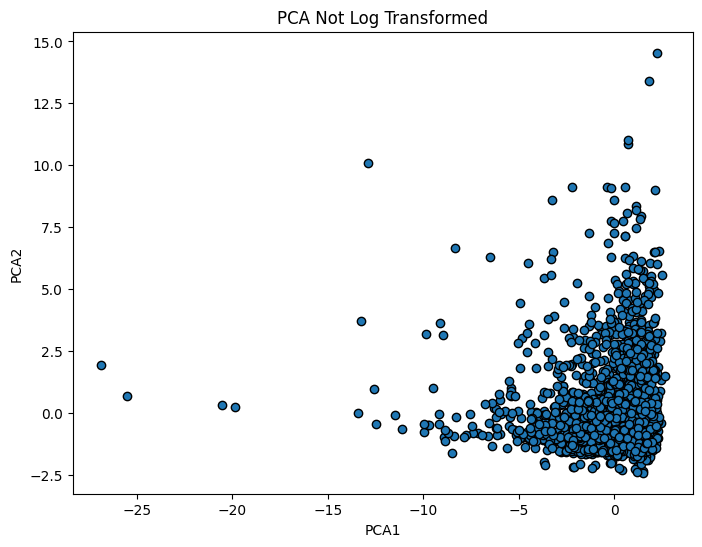

In [644]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(listings_for_dim_reduc)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1],cmap='viridis', edgecolors='k')
plt.title('PCA Not Log Transformed')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

Before log transforming the data, we found that in the pca all of the point concentrated in this corner and loosely spread along
the axis. Some research indicated this could be a result of skewedness so we tried log transforming the data

<positron-console-cell-653>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


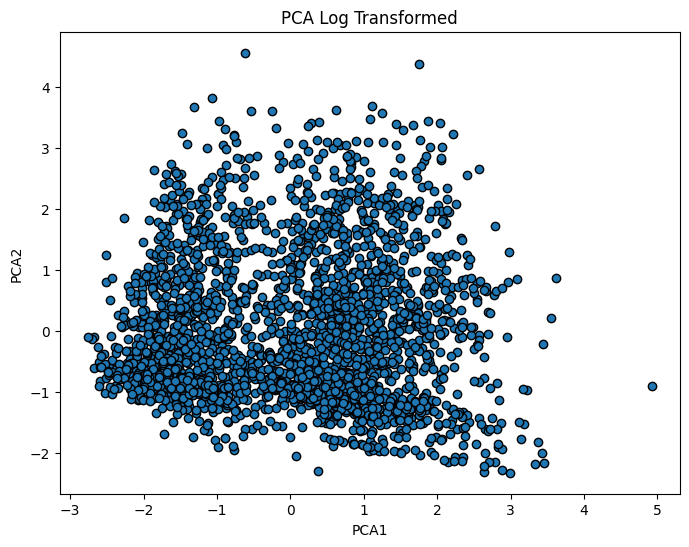

In [653]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(listings_for_dim_reduc_log)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1],cmap='viridis', edgecolors='k')
plt.title('PCA Log Transformed')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

applying the log transform helped spread the points, but pca was not doing well at capturing any structure. So we moved on to trying a different approach with umap and continuing with
the log transformed data.

## UMAP

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
<positron-console-cell-654>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


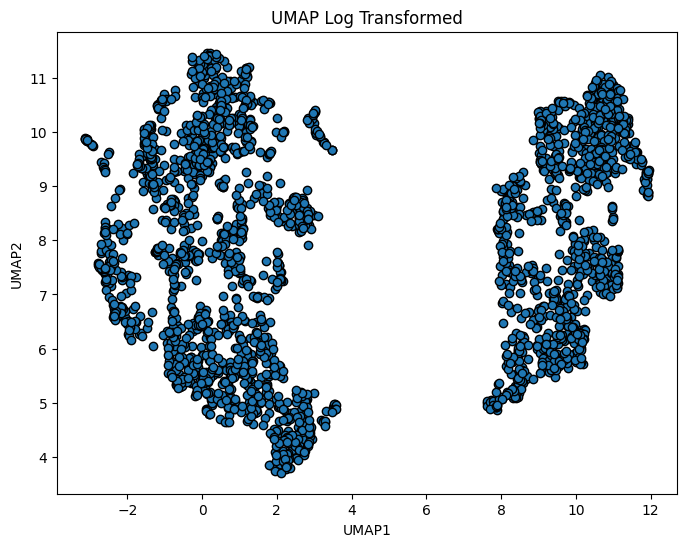

In [654]:
umap_model = umap.UMAP(n_components=2,metric='euclidean')
umap_result = umap_model.fit_transform(listings_for_dim_reduc_log)

plt.figure(figsize=(8, 6))
plt.scatter(umap_result[:, 0], umap_result[:, 1],cmap='viridis', edgecolors='k')
plt.title('UMAP Log Transformed')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()


we saw a more distict separation with umap and decided to use it going forward

## combine umap and pca plots for report

<positron-console-cell-655>:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
<positron-console-cell-655>:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


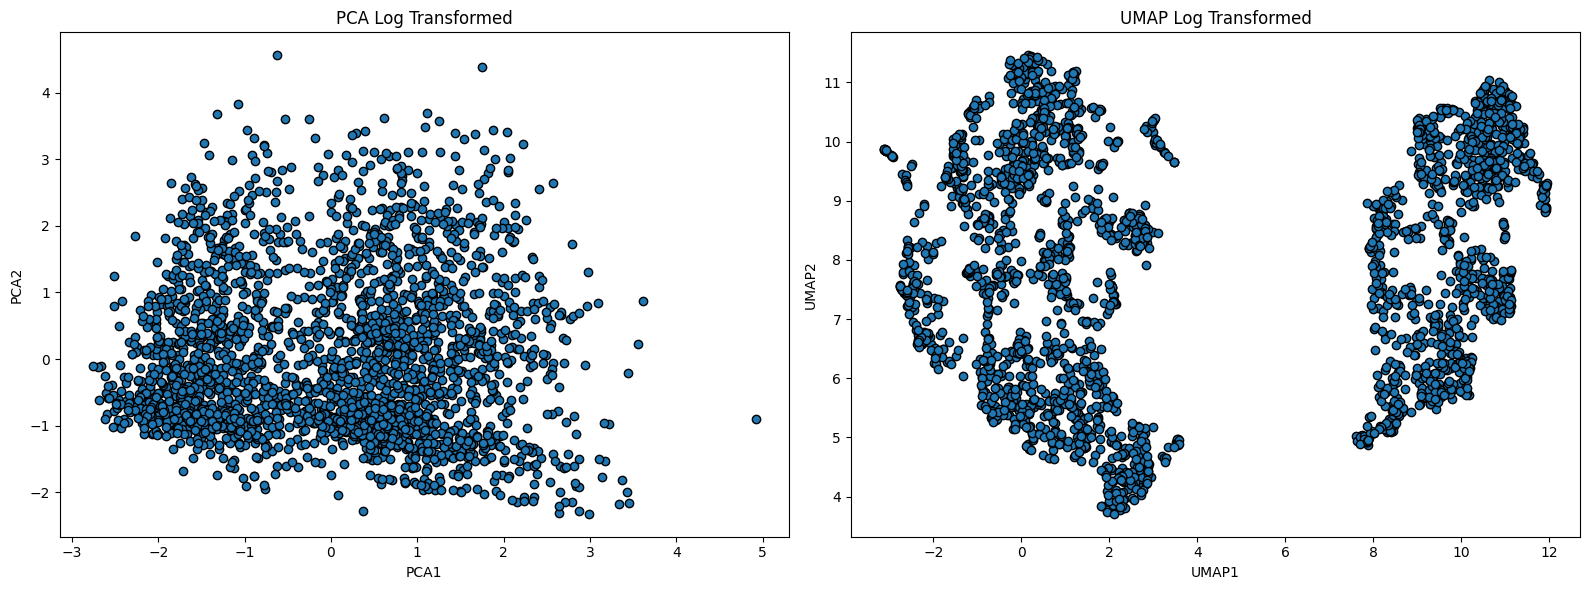

In [655]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(pca_result[:, 0], pca_result[:, 1], cmap='viridis', edgecolors='k')
axes[0].set_title('PCA Log Transformed')
axes[0].set_xlabel('PCA1')
axes[0].set_ylabel('PCA2')

scatter = axes[1].scatter(umap_result[:, 0], umap_result[:, 1], 
                           cmap='viridis', edgecolors='k')
axes[1].set_title('UMAP Log Transformed')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')


plt.tight_layout()
plt.show()

## explore distance metrics

we first wanted to explor how changing the the distance metrics in umap would affect our data

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for 

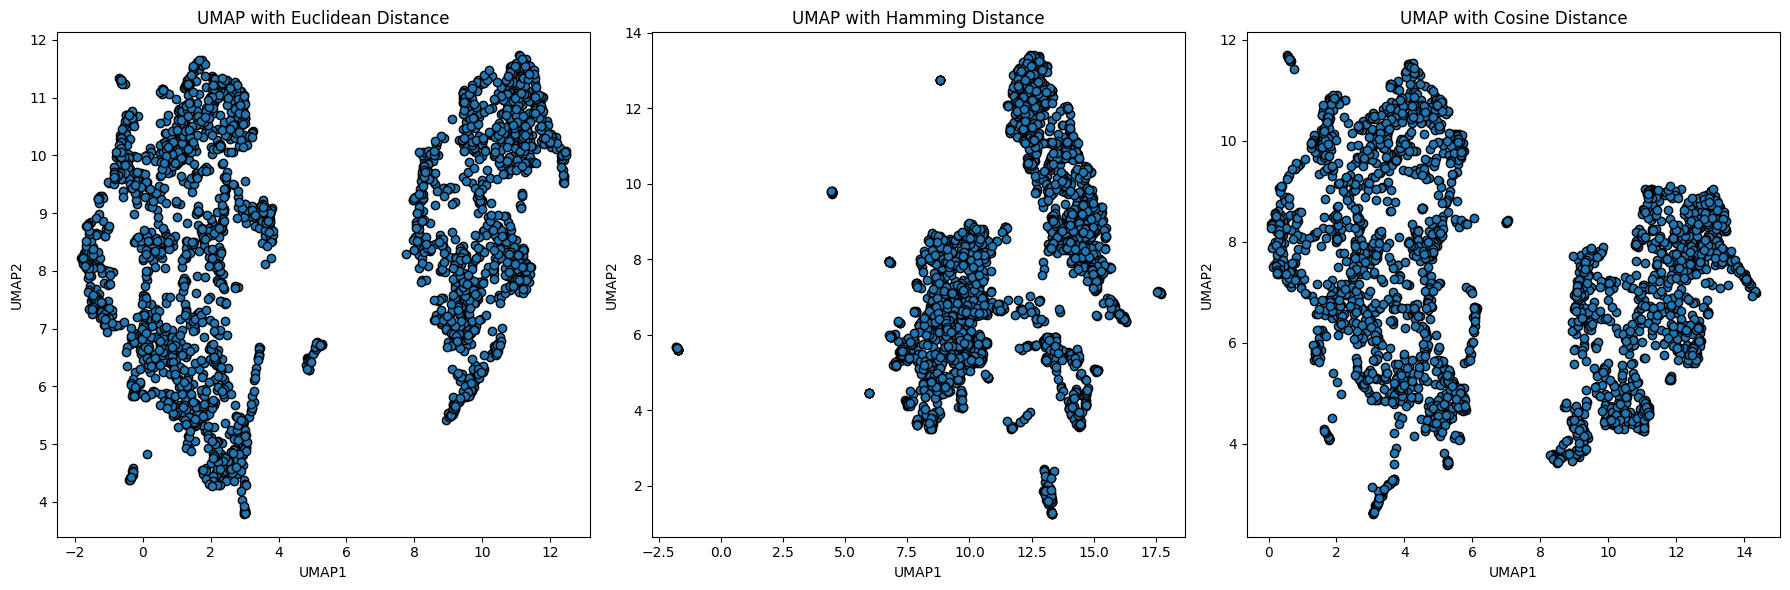

In [657]:
umap_euclidean = umap.UMAP(n_components=2, metric='euclidean',random_state=42)
umap_euclidean_result = umap_euclidean.fit_transform(listings_for_dim_reduc_log)

umap_hamming = umap.UMAP(n_components=2, metric='hamming',random_state=42)
umap_hamming_result = umap_hamming.fit_transform(listings_for_dim_reduc_log)

umap_cosine = umap.UMAP(n_components=2, metric='cosine',random_state=42)
umap_cosine_result = umap_cosine.fit_transform(listings_for_dim_reduc_log)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(umap_euclidean_result[:, 0], umap_euclidean_result[:, 1], cmap='viridis', edgecolors='k')
axes[0].set_title('UMAP with Euclidean Distance')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')

axes[1].scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], cmap='viridis', edgecolors='k')
axes[1].set_title('UMAP with Hamming Distance')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

axes[2].scatter(umap_cosine_result[:, 0], umap_cosine_result[:, 1], cmap='viridis', edgecolors='k')
axes[2].set_title('UMAP with Cosine Distance')
axes[2].set_xlabel('UMAP1')
axes[2].set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

we noticed that hamming distance resulted in smaller more distinct clusters and had the biggest difference from the default. This could be due to the 
overrepresentation of one hot encoded columns in our transformed data and seemed like a good candidate to move forward tuning with.

## Tuning UMAP

As n_neighbors and min_dist are the most important hyperparameters for umap we used a manual gridsearch-like approach to fit and compare these models visually

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; in

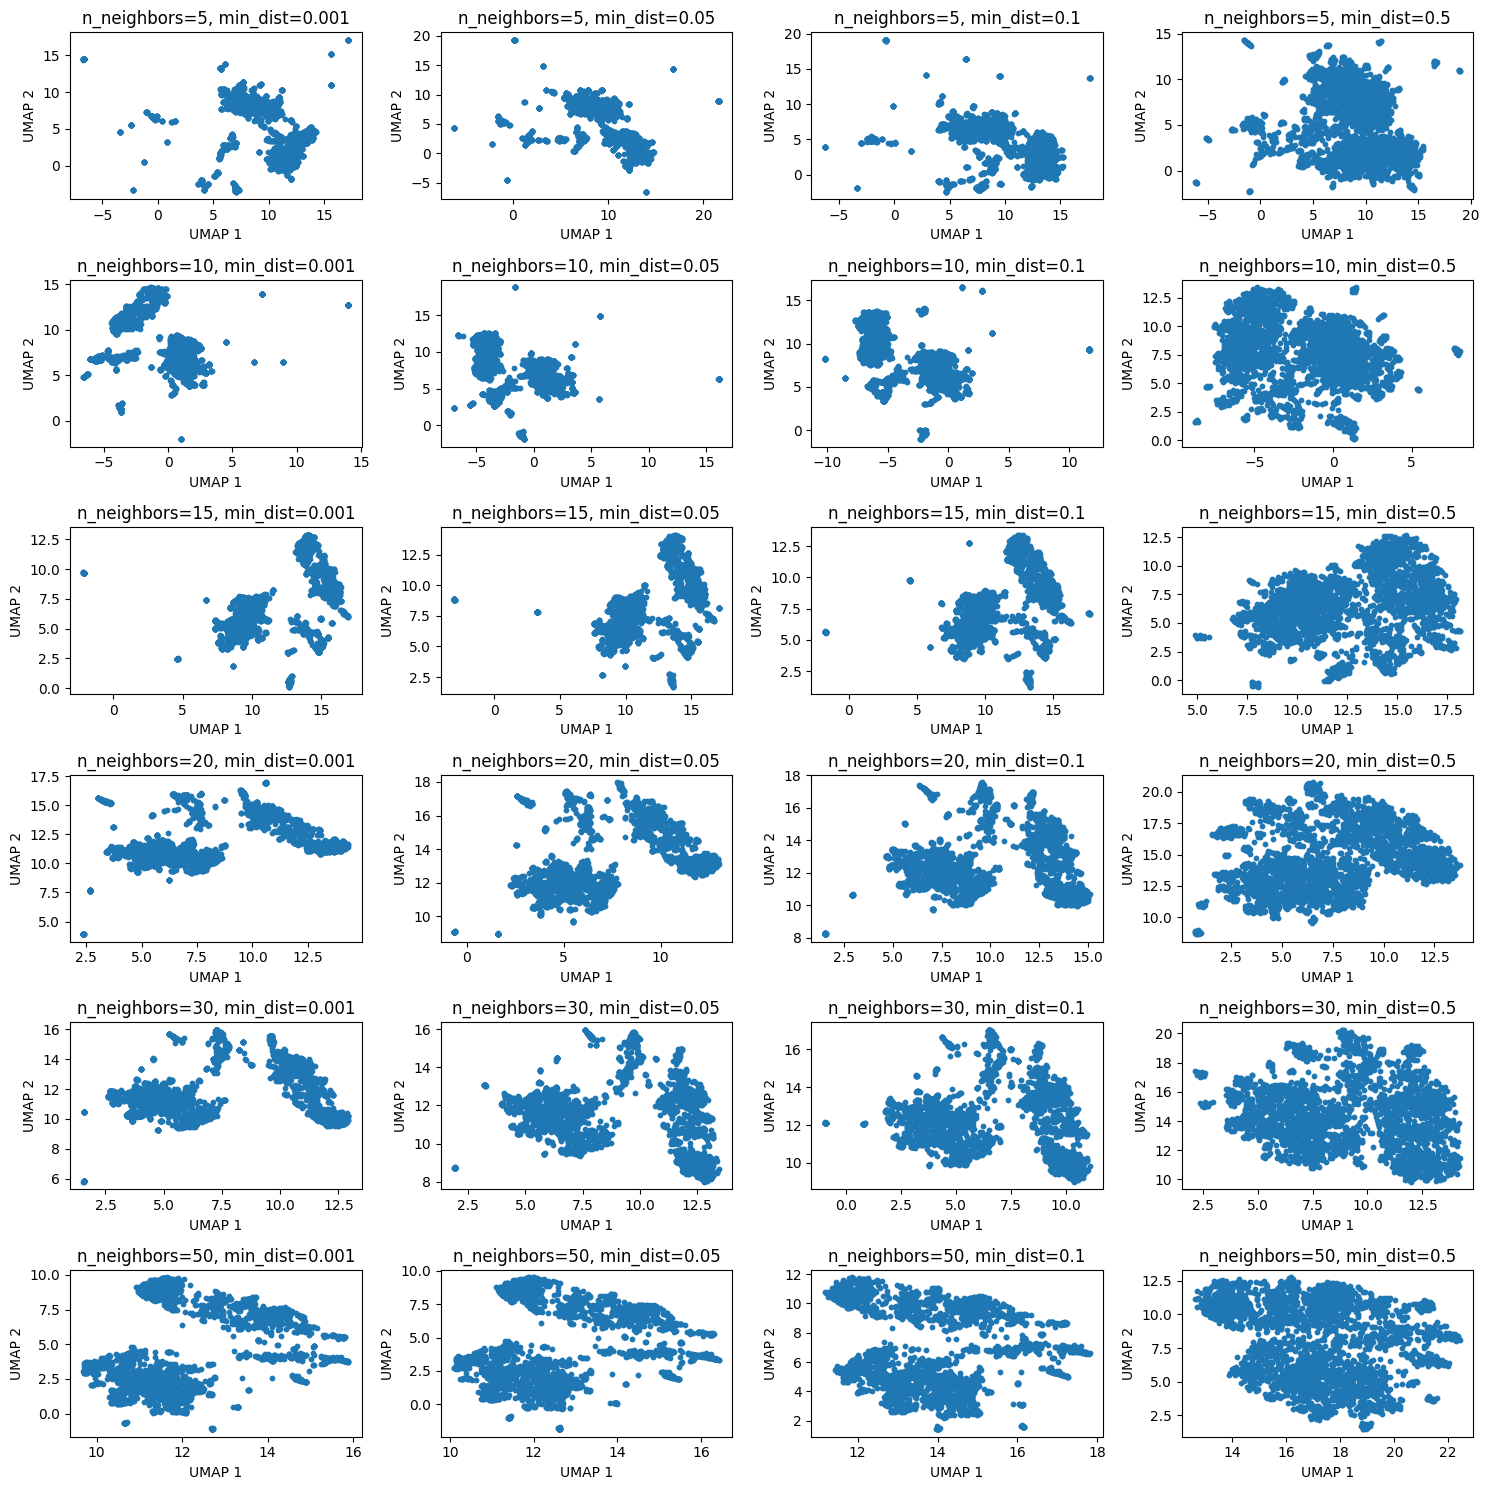

In [658]:
n_neighbors_range = [5, 10, 15,20, 30, 50]
min_dist_range = [0.001, 0.05, 0.1, 0.5]

results = []


for n_neighbors in n_neighbors_range:
    for min_dist in min_dist_range:
        umap_model = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, metric='hamming', random_state=42)
        umap_result = umap_model.fit_transform(listings_for_dim_reduc_log)
        
        results.append({
            'n_neighbors': n_neighbors,
            'min_dist': min_dist,
            'umap_result': umap_result
        })

fig, axes = plt.subplots(len(n_neighbors_range), len(min_dist_range), figsize=(15, 15))

for i, n_neighbors in enumerate(n_neighbors_range):
    for j, min_dist in enumerate(min_dist_range):

        umap_result = results[(i * len(min_dist_range)) + j]['umap_result']
        
        ax = axes[i, j]
        ax.scatter(umap_result[:, 0], umap_result[:, 1], s=10, cmap='viridis')
        ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()


from the above we found that n_neighbors=20 and min_dist=1 seemed to be a good tradeoff between cluster structure and explained variance. A more detailed explanation
can be found in the written report but we moved forward with these parameters.

In [781]:
umap_hamming = umap.UMAP(n_components=2, metric='hamming',min_dist=.1,n_neighbors=20,random_state=42)
umap_hamming_result = umap_hamming.fit_transform(listings_for_dim_reduc_log)

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


from here we will attempt to cluster these results for evaluation

## Clustering 

From the above plots we know that our data consists of large dense clusters surrounded by smaller outliers. Because of this we know that methods like kmeans will not
work well and should use something like HDBSCAN or DBSCAN which are density based and deal with outliers well. We chode hdbscan. In HDBSCAN, min_cluster_size is generally
the most important parameter so we started testing it by calculating the clusters silhouette score for the model at different cluster sizes.

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' wa

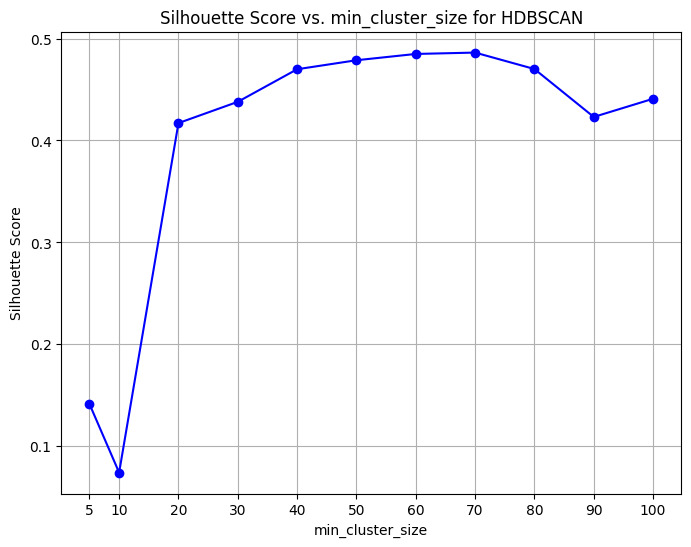

In [782]:
min_cluster_sizes = [5, 10, 20, 30, 40, 50,60,70,80,90,100]
silhouette_scores = []

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_size)
    cluster_labels = clusterer.fit_predict(umap_hamming_result)

    if len(set(cluster_labels)) > 1:
        score = silhouette_score(umap_hamming_result, cluster_labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)

plt.figure(figsize=(8, 6))
plt.plot(min_cluster_sizes, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title("Silhouette Score vs. min_cluster_size for HDBSCAN")
plt.xlabel("min_cluster_size")
plt.ylabel("Silhouette Score")
plt.xticks(min_cluster_sizes)
plt.grid(True)
plt.show()


we see that the highest score is at 70, though in testing it seems like large cluster sizes will always trend higher as it is an average. The first immediate jump is at 20 so that
value also seems interesting. next we will look into the elbow method with the same process.

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' wa

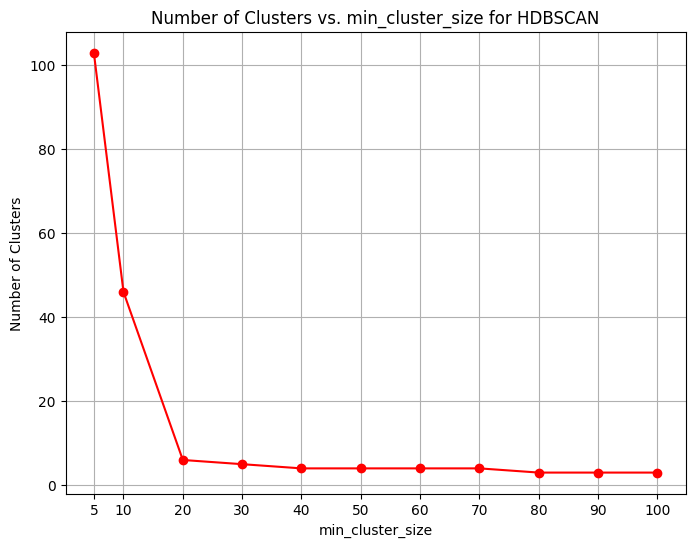

In [783]:
min_cluster_sizes = [5, 10, 20, 30, 40, 50,60,70,80,90,100]
num_clusters = []

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_size)
    cluster_labels = clusterer.fit_predict(umap_hamming_result)
    
    num_clusters.append(len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0))

plt.figure(figsize=(8, 6))
plt.plot(min_cluster_sizes, num_clusters, marker='o', linestyle='-', color='r')
plt.title("Number of Clusters vs. min_cluster_size for HDBSCAN")
plt.xlabel("min_cluster_size")
plt.ylabel("Number of Clusters")
plt.xticks(min_cluster_sizes)
plt.grid(True)
plt.show()


The elbow method seems to more strongly indicate that 20 is the optimal value, but we will look at the silhouette scores more closely to try and confirm.

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


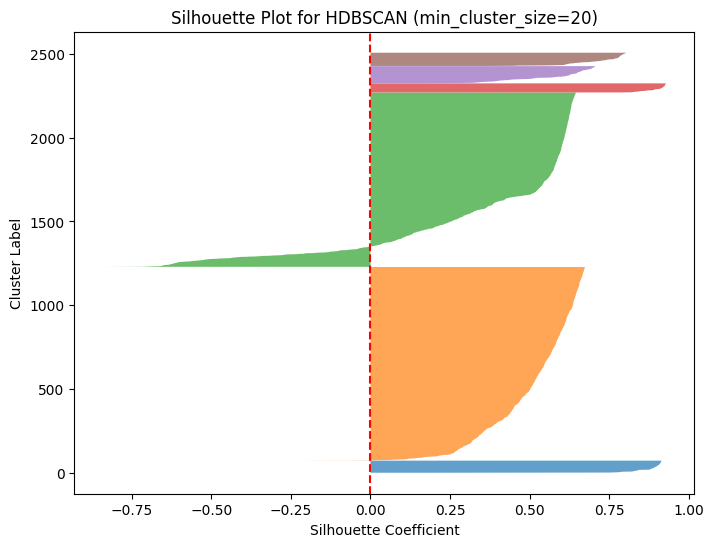

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


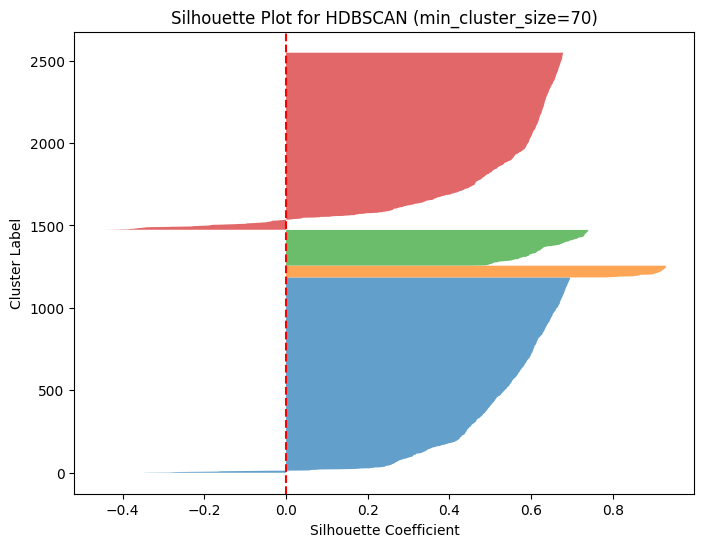

In [785]:
def plot_silhouette(umap_data, cluster_labels, min_cluster_size):
    valid_labels = cluster_labels != -1
    valid_data = umap_data[valid_labels]
    valid_labels = cluster_labels[valid_labels]

    silhouette_vals = silhouette_samples(valid_data, valid_labels)

    plt.figure(figsize=(8, 6))
    plt.title(f"Silhouette Plot for HDBSCAN (min_cluster_size={min_cluster_size})")
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster Label")

    y_lower, y_upper = 0, 0
    for i in np.unique(valid_labels):
        cluster_silhouette_vals = silhouette_vals[valid_labels == i]
        cluster_silhouette_vals.sort()

        cluster_size = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + cluster_size

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=0, color="red", linestyle="--")
    plt.show()

clusterer_20 = hdbscan.HDBSCAN(min_cluster_size=20)
cluster_labels_20 = clusterer_20.fit_predict(umap_hamming_result)
plot_silhouette(umap_hamming_result, cluster_labels_20, min_cluster_size=20)

clusterer_70 = hdbscan.HDBSCAN(min_cluster_size=70)
cluster_labels_70 = clusterer_70.fit_predict(umap_hamming_result)
plot_silhouette(umap_hamming_result, cluster_labels_70, min_cluster_size=70)



C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


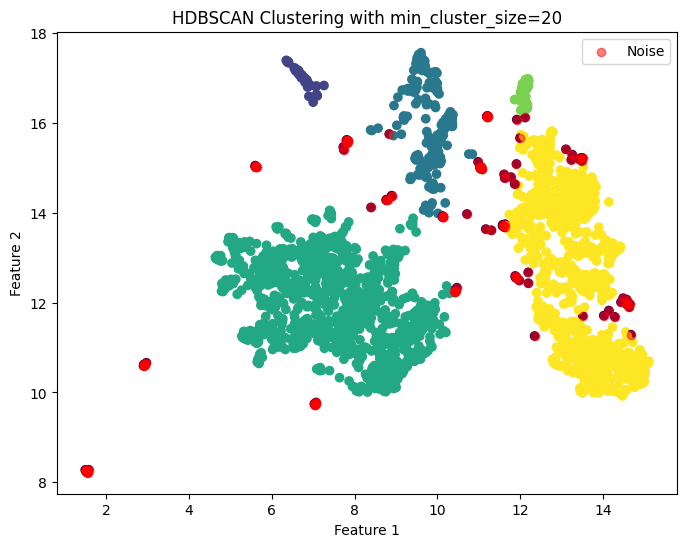

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


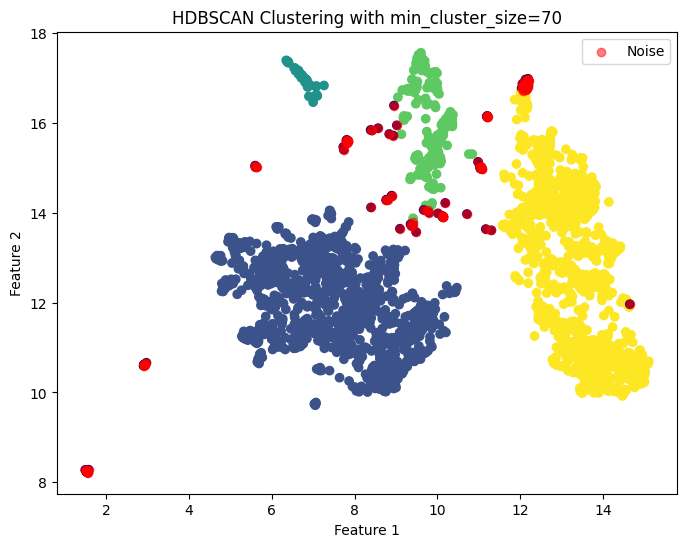

In [786]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=30)
cluster_labels = clusterer.fit_predict(umap_hamming_result)
plt.figure(figsize=(8, 6))

plt.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=cluster_labels, cmap='viridis', marker='o')

plt.scatter(umap_hamming_result[cluster_labels == -1, 0], 
            umap_hamming_result[cluster_labels == -1, 1], 
            color='red', label='Noise', alpha=0.5)

plt.title("HDBSCAN Clustering with min_cluster_size=20")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

clusterer = hdbscan.HDBSCAN(min_cluster_size=60)
cluster_labels = clusterer.fit_predict(umap_hamming_result)
plt.figure(figsize=(8, 6))

plt.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=cluster_labels, cmap='viridis', marker='o')

plt.scatter(umap_hamming_result[cluster_labels == -1, 0], 
            umap_hamming_result[cluster_labels == -1, 1], 
            color='red', label='Noise', alpha=0.5)

plt.title("HDBSCAN Clustering with min_cluster_size=70")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Now we can see that the min_cluster_size of 70 seems to have trouble with noise around the edges of the larger clusters. This seems to show that the large values
of min cluster alone seem to have more trouble. Next we want to see if adding min_sample can help in defining some of these clusters. Similarly to before we use 
a manual gridsearch-like approach  to assess combinations of these parameters

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' wa

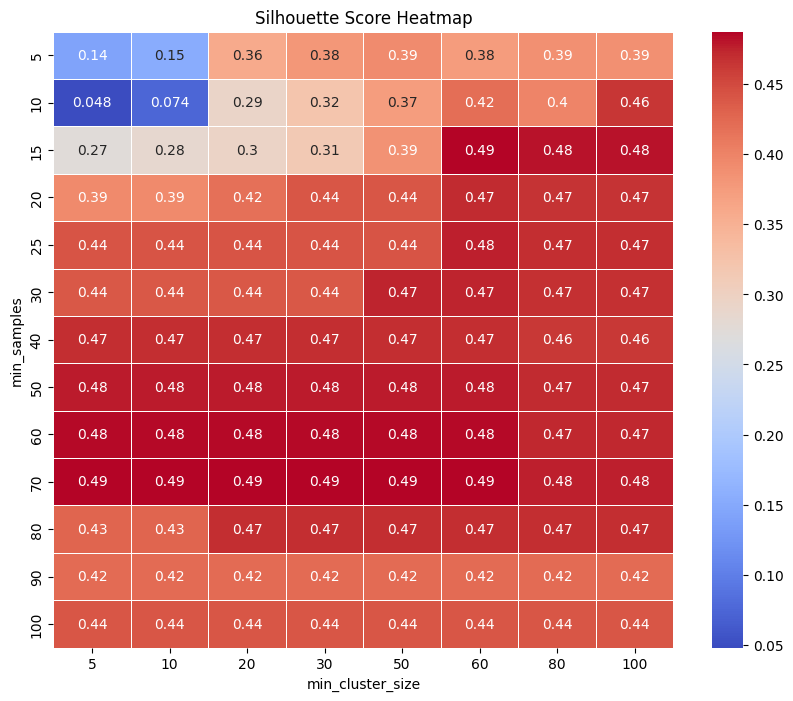

In [787]:
min_cluster_sizes = [5, 10, 20, 30, 50, 60, 80, 100]  
min_samples_values = [5, 10, 15, 20, 25, 30,40,50,60,70,80,90,100]

results = []

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:

        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        cluster_labels = clusterer.fit_predict(umap_hamming_result)
        
        if len(set(cluster_labels)) <= 1:
            continue
        
        silhouette_avg = silhouette_score(umap_hamming_result, cluster_labels)

        results.append({
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'silhouette_score': silhouette_avg
        })

results_df = pd.DataFrame(results)


pivot_silhouette = results_df.pivot(index='min_samples', columns='min_cluster_size', values='silhouette_score')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_silhouette, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Silhouette Score Heatmap")
plt.xlabel("min_cluster_size")
plt.ylabel("min_samples")
plt.show()

we can see from the heatmap that many combinations share the highest silhouette score but lets see what makes them different.

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


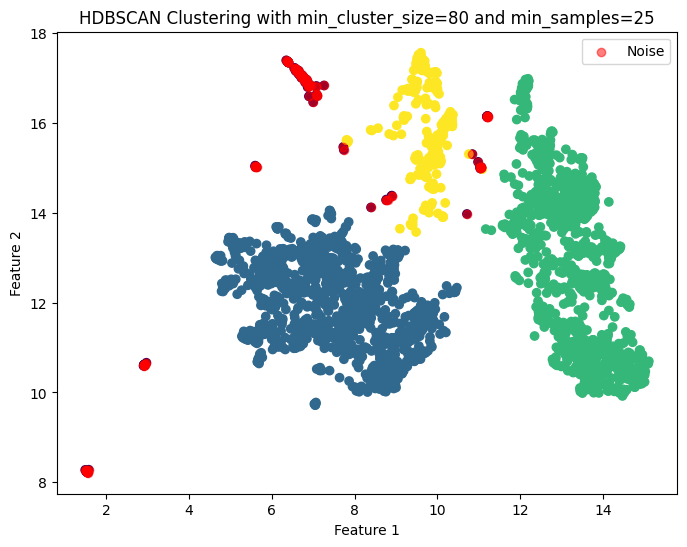

In [801]:
import hdbscan
import matplotlib.pyplot as plt

clusterer = hdbscan.HDBSCAN(min_cluster_size=80,min_samples=15)
cluster_labels = clusterer.fit_predict(umap_hamming_result)

plt.figure(figsize=(8, 6))

plt.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=cluster_labels, cmap='viridis', marker='o')

plt.scatter(umap_hamming_result[cluster_labels == -1, 0], 
            umap_hamming_result[cluster_labels == -1, 1], 
            color='red', label='Noise', alpha=0.5)

plt.title("HDBSCAN Clustering with min_cluster_size=80 and min_samples=15")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


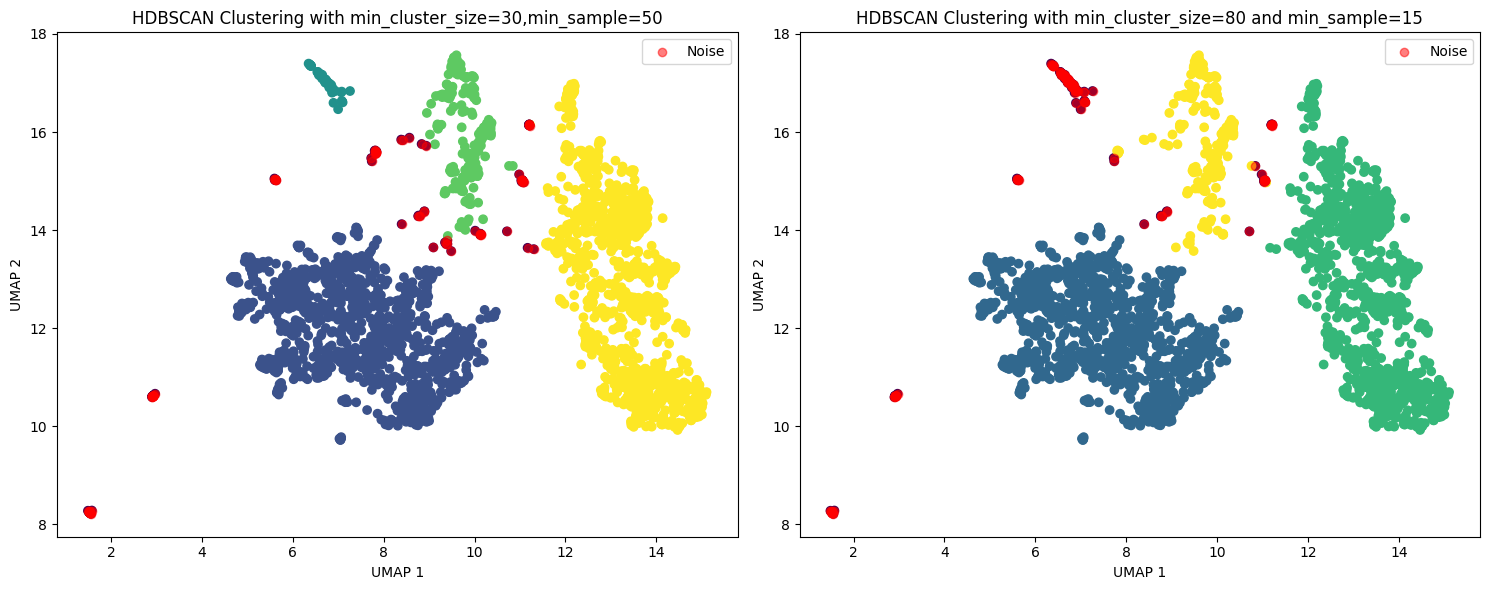

In [804]:
clusterer_1 = hdbscan.HDBSCAN(min_cluster_size=30,min_samples=50)
cluster_labels_1 = clusterer_1.fit_predict(umap_hamming_result)
clusterer_2 = hdbscan.HDBSCAN(min_cluster_size=80,min_samples=15)
cluster_labels_2 = clusterer_2.fit_predict(umap_hamming_result)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=cluster_labels_1, cmap='viridis', marker='o')
axes[0].scatter(umap_hamming_result[cluster_labels_1 == -1, 0], 
                umap_hamming_result[cluster_labels_1 == -1, 1], 
                color='red', label='Noise', alpha=0.5)
axes[0].set_title("HDBSCAN Clustering with min_cluster_size=30,min_sample=50")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend()

axes[1].scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=cluster_labels_2, cmap='viridis', marker='o')
axes[1].scatter(umap_hamming_result[cluster_labels_2 == -1, 0], 
                umap_hamming_result[cluster_labels_2 == -1, 1], 
                color='red', label='Noise', alpha=0.5)
axes[1].set_title("HDBSCAN Clustering with min_cluster_size=80 and min_sample=15")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


We see that there is a trend with higher min cluster sizes resulting in the removal of smaller clusters that do not seem to be just noise, so we
will stick with the smaller cluster size of 30 and the best min_sample size for silhouette score

# Understanding the structure of our clusters

now that we understand where are clusters are and that they are well definined lets see how the structure is influenced by our features.

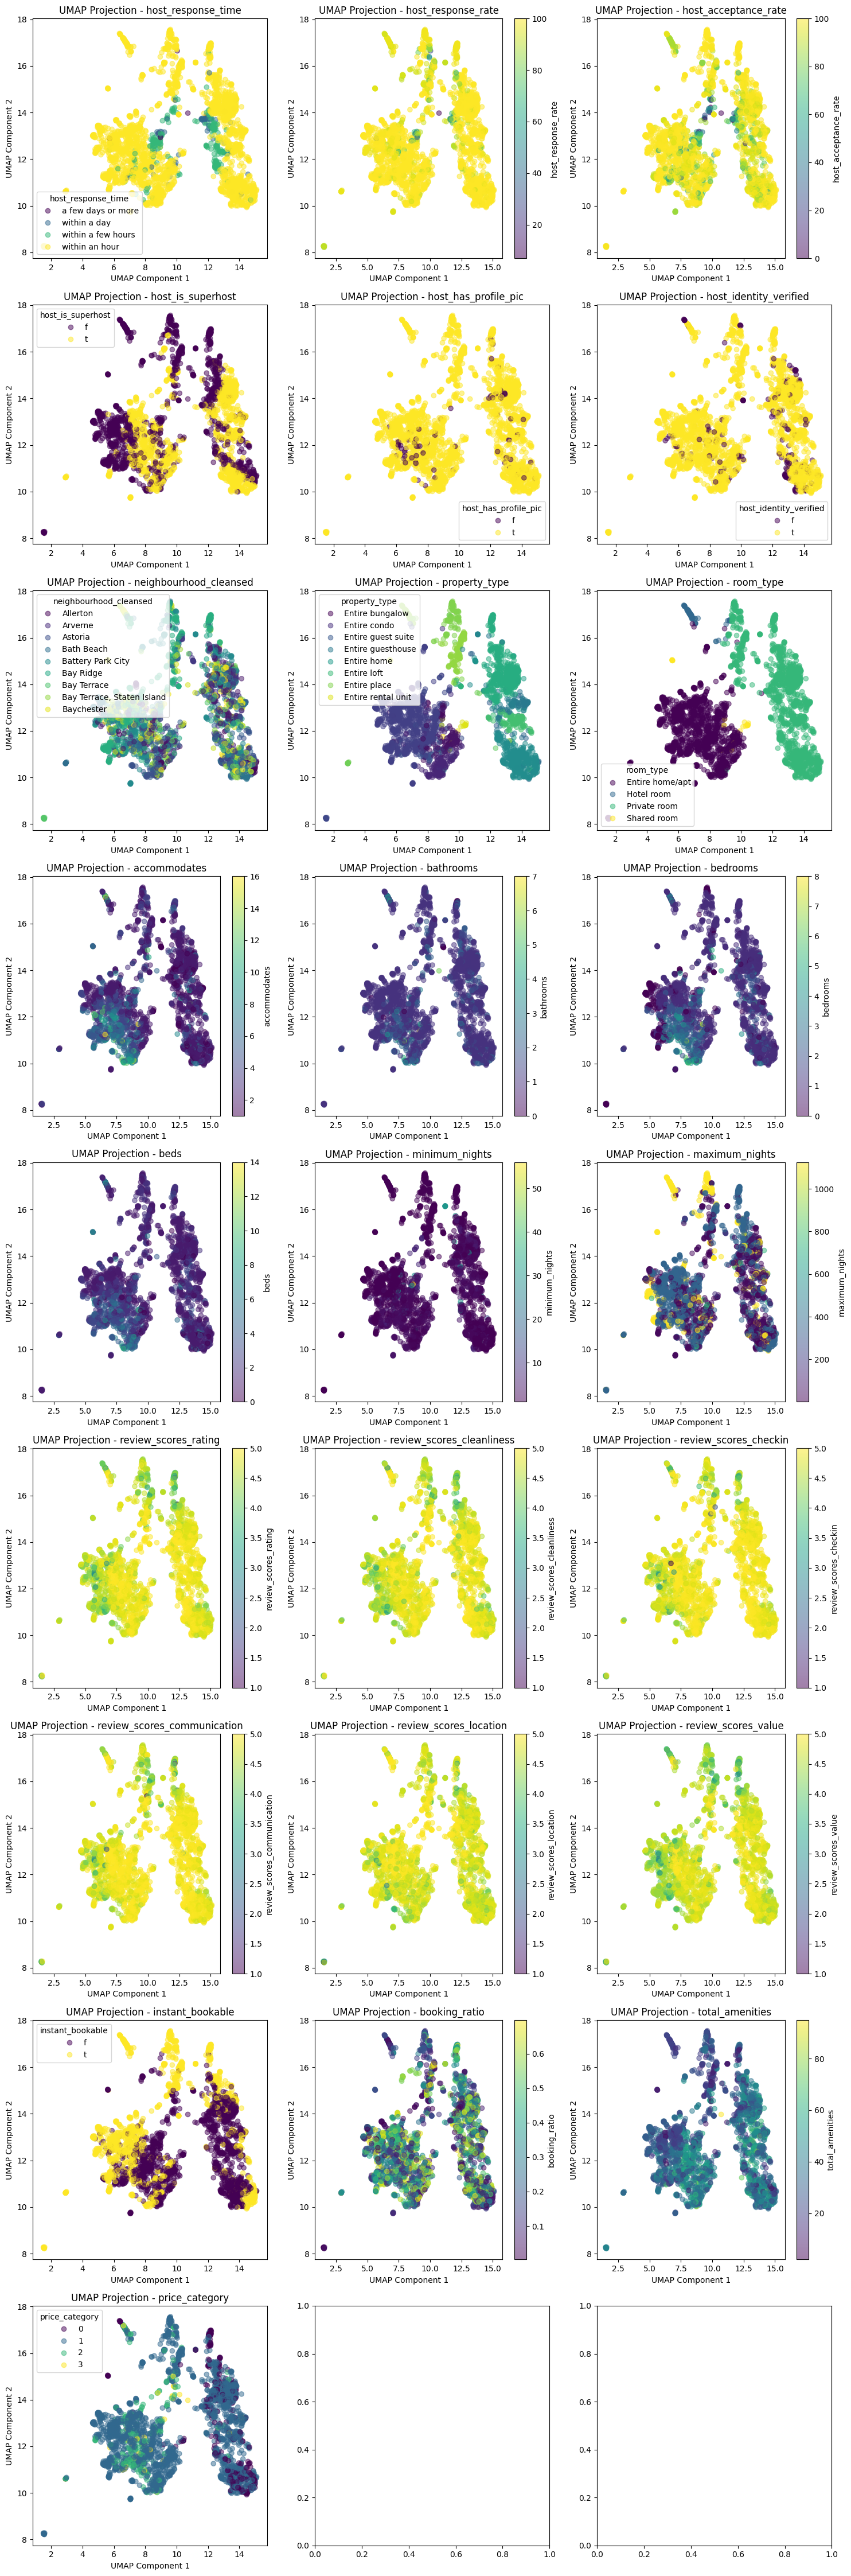

In [806]:
n_cols = 3
n_rows = int(np.ceil(len(listings.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

axes = axes.flatten()

for idx, column in enumerate(listings.columns):
    ax = axes[idx] 

    if listings[column].dtype == 'object' or listings[column].dtype.name == 'category':

        label_encoder = LabelEncoder()
        encoded_column = label_encoder.fit_transform(listings[column])
        
        scatter = ax.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=encoded_column,alpha=.5)
        
        ax.set_title(f"UMAP Projection - {column}")
        ax.set_xlabel("UMAP Component 1")
        ax.set_ylabel("UMAP Component 2")
        
        handles, labels = scatter.legend_elements()
        ax.legend(handles, label_encoder.classes_, title=column)

    elif np.issubdtype(listings[column].dtype, np.number):
        scatter = ax.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=listings[column],alpha=.5)
        
        ax.set_title(f"UMAP Projection - {column}")
        ax.set_xlabel("UMAP Component 1")
        ax.set_ylabel("UMAP Component 2")
        plt.colorbar(scatter, ax=ax, label=column)

plt.tight_layout()

plt.show()

It looks like some notable features that seem to contribute to these clusters are property_type, room_type, bedrooms, beds, and accomadates.
We even see that price category is split across these boundaries as well. Lets look closer.

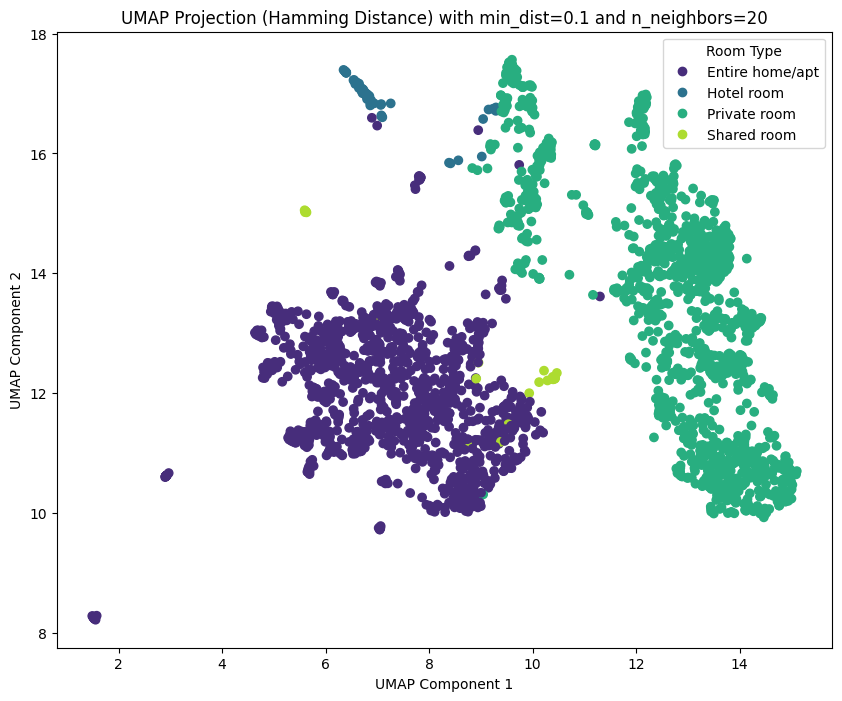

In [807]:
label_encoder = LabelEncoder()
encoded_neighbourhood = label_encoder.fit_transform(listings['room_type'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=encoded_neighbourhood)

plt.clim(-0.5, len(label_encoder.classes_) - 0.5)

handles, labels = scatter.legend_elements()
plt.legend(handles, label_encoder.classes_, title="Room Type")

plt.title("UMAP Projection (Hamming Distance) with min_dist=0.1 and n_neighbors=20")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.show()

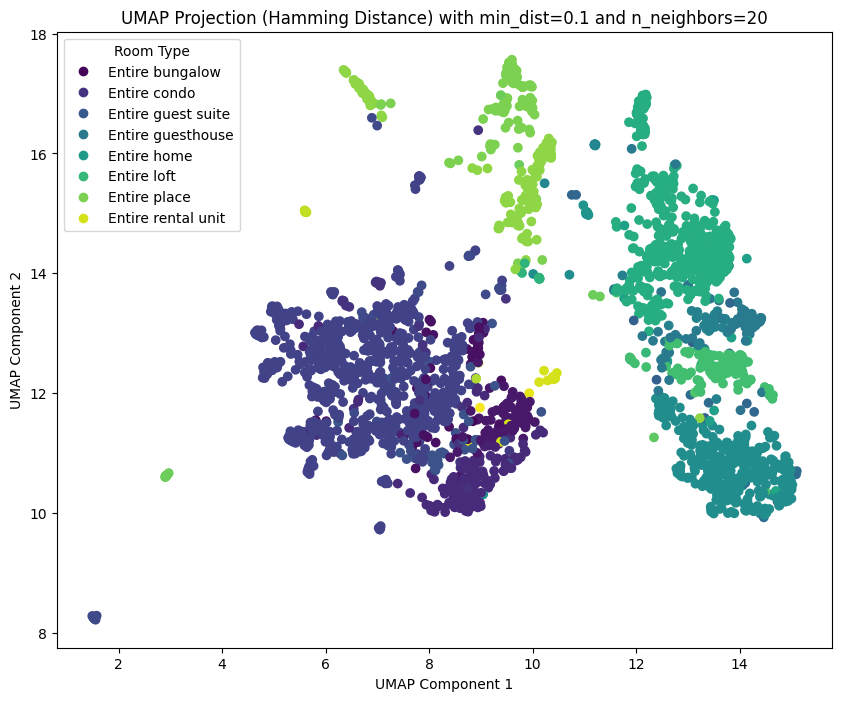

In [808]:
label_encoder = LabelEncoder()
encoded_neighbourhood = label_encoder.fit_transform(listings['property_type'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=encoded_neighbourhood)

plt.clim(-0.5, len(label_encoder.classes_) - 0.5)

handles, labels = scatter.legend_elements()
plt.legend(handles, label_encoder.classes_, title="Room Type")

plt.title("UMAP Projection (Hamming Distance) with min_dist=0.1 and n_neighbors=20")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.show()

## make plot for report

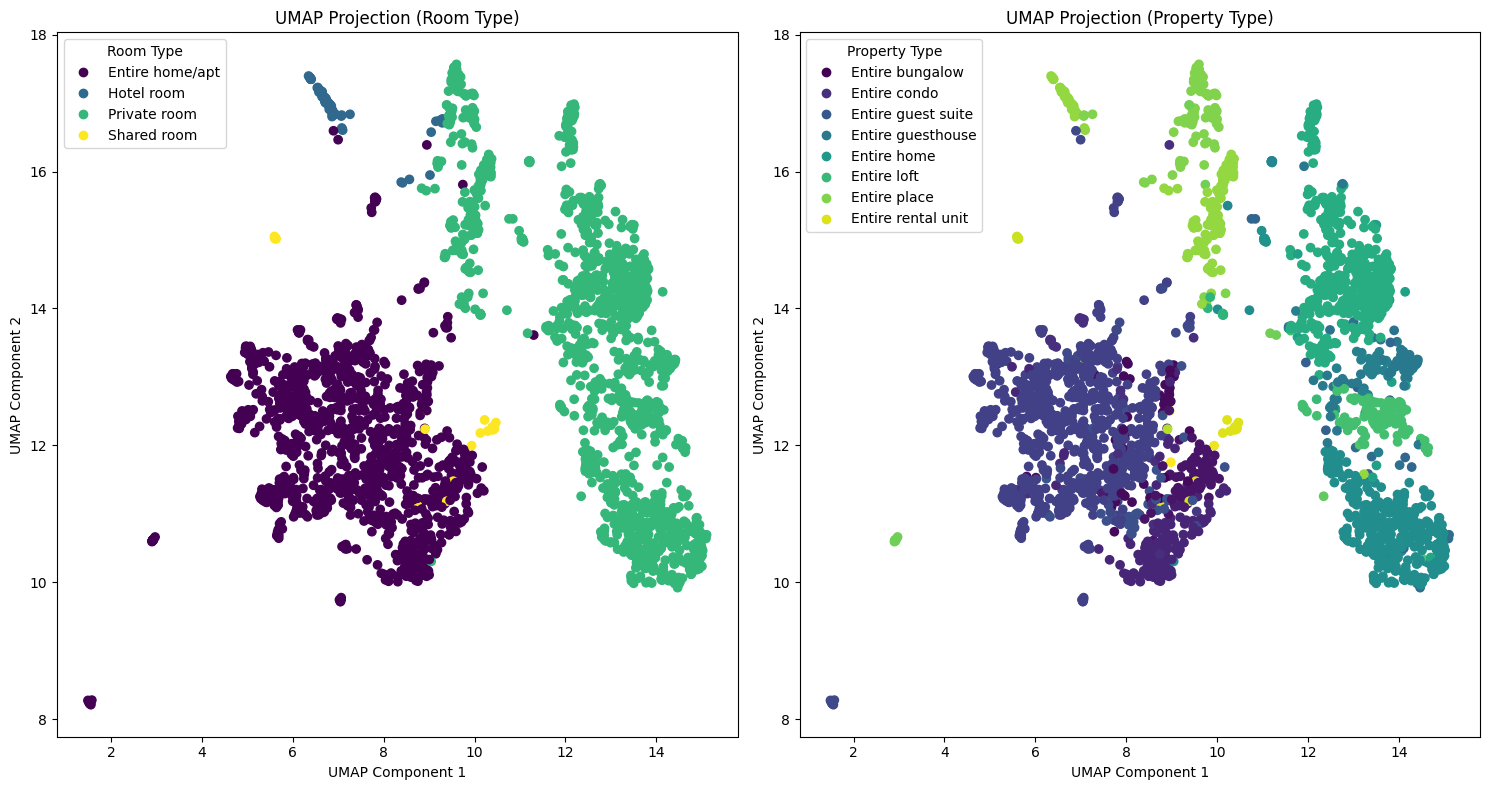

In [809]:
label_encoder_room_type = LabelEncoder()
encoded_room_type = label_encoder_room_type.fit_transform(listings['room_type'])

label_encoder_property_type = LabelEncoder()
encoded_property_type = label_encoder_property_type.fit_transform(listings['property_type'])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))


scatter1 = axes[0].scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=encoded_room_type)
axes[0].set_title("UMAP Projection (Room Type)")
axes[0].set_xlabel("UMAP Component 1")
axes[0].set_ylabel("UMAP Component 2")


handles, labels = scatter1.legend_elements()
axes[0].legend(handles, label_encoder_room_type.classes_, title="Room Type")

scatter2 = axes[1].scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=encoded_property_type)
axes[1].set_title("UMAP Projection (Property Type)")
axes[1].set_xlabel("UMAP Component 1")
axes[1].set_ylabel("UMAP Component 2")

handles, labels = scatter2.legend_elements()
axes[1].legend(handles, label_encoder_property_type.classes_, title="Property Type")

plt.tight_layout()


plt.show()


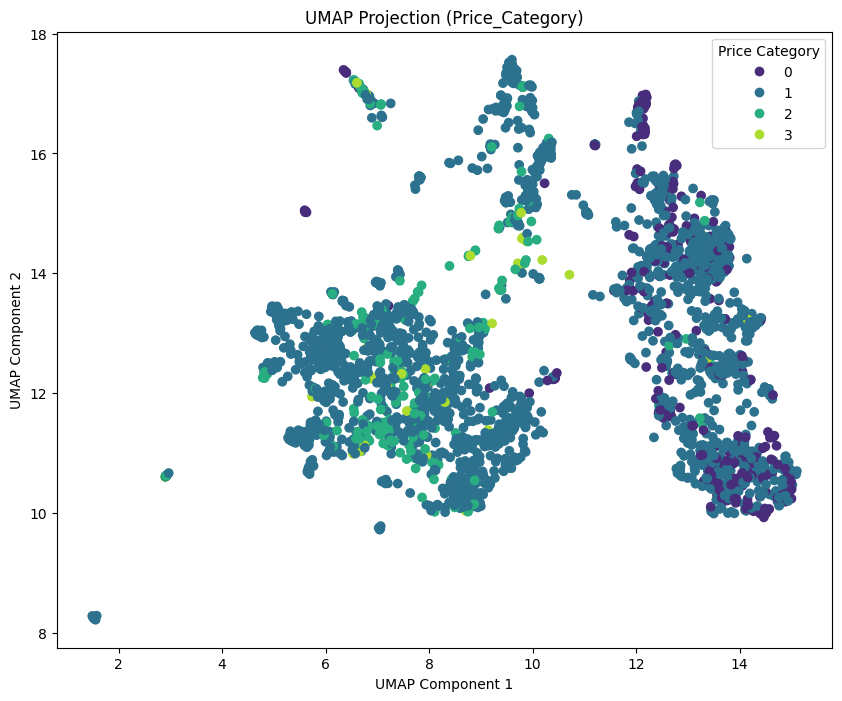

In [810]:
label_encoder = LabelEncoder()
encoded_neighbourhood = label_encoder.fit_transform(listings['price_category'])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], c=encoded_neighbourhood)

plt.clim(-0.5, len(label_encoder.classes_) - 0.5)

handles, labels = scatter.legend_elements()
plt.legend(handles, label_encoder.classes_, title="Price Category")

plt.title("UMAP Projection (Price_Category)")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.show()

we see that private rooms are likely to be much cheaper than entire homes, which definitely makes sense in regards to a 
rental price.

# Feature Sensitivity
now that we know property and room type are major players in our datas structure lets see what happens when they are removed

C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
C:\Users\Jacob\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for 

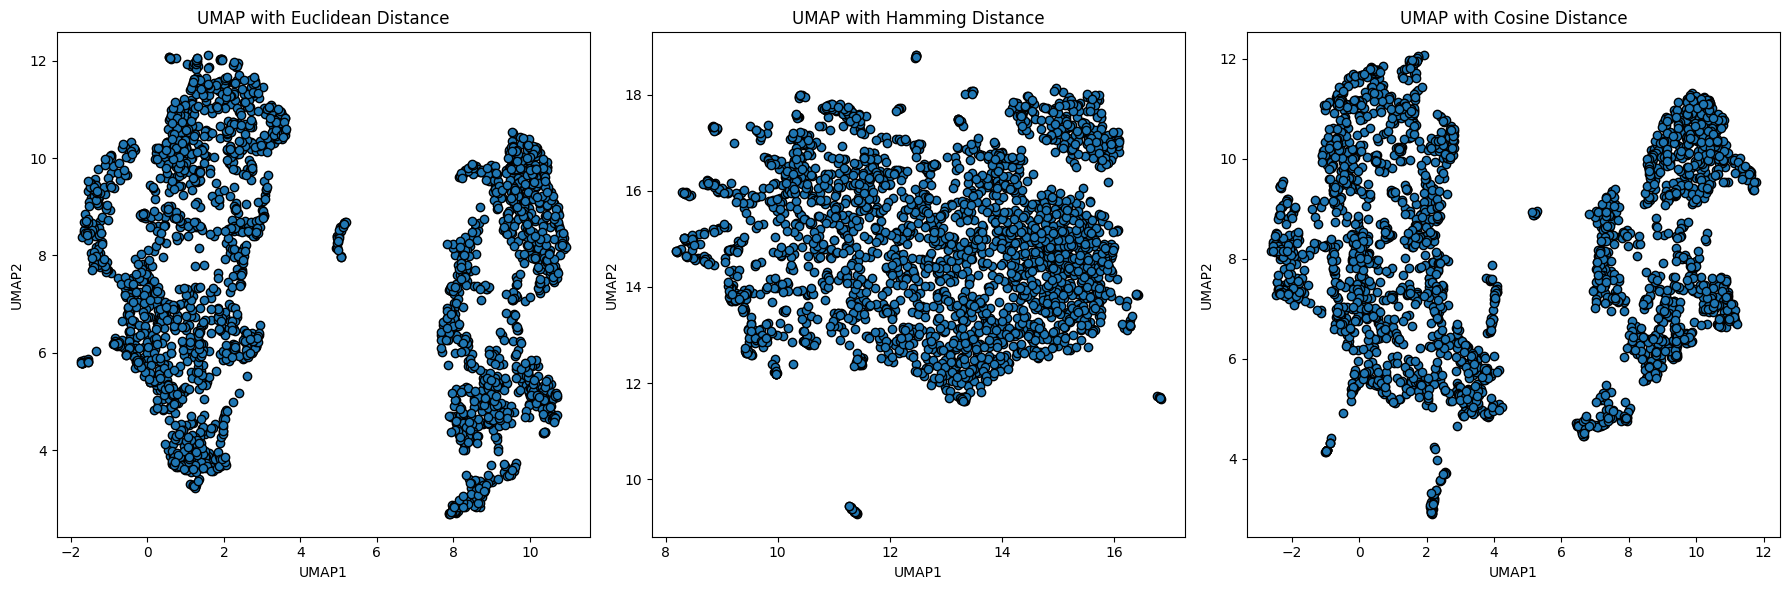

In [812]:
columns_to_remove = [col for col in listings_for_dim_reduc_log.columns if col.startswith('property_type') or col.startswith('room_type')]

df = listings_for_dim_reduc_log.copy()
df_cleaned = df.drop(columns=columns_to_remove)

umap_euclidean = umap.UMAP(n_components=2, metric='euclidean',random_state=42)
umap_euclidean_result = umap_euclidean.fit_transform(df_cleaned)

umap_hamming = umap.UMAP(n_components=2, metric='hamming',random_state=42)
umap_hamming_result = umap_hamming.fit_transform(df_cleaned)

umap_cosine = umap.UMAP(n_components=2, metric='cosine',random_state=42)
umap_cosine_result = umap_cosine.fit_transform(df_cleaned)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(umap_euclidean_result[:, 0], umap_euclidean_result[:, 1], cmap='viridis', edgecolors='k')
axes[0].set_title('UMAP with Euclidean Distance')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')

axes[1].scatter(umap_hamming_result[:, 0], umap_hamming_result[:, 1], cmap='viridis', edgecolors='k')
axes[1].set_title('UMAP with Hamming Distance')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

axes[2].scatter(umap_cosine_result[:, 0], umap_cosine_result[:, 1], cmap='viridis', edgecolors='k')
axes[2].set_title('UMAP with Cosine Distance')
axes[2].set_xlabel('UMAP1')
axes[2].set_ylabel('UMAP2')

plt.tight_layout()
plt.show()